In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [9]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_customer_data_custom_ratios.csv to ecommerce_customer_data_custom_ratios (1).csv


In [10]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [11]:
# Dataset information

print("Shape of dataset:", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (250000, 13)

Column data types:
Customer ID                int64
Purchase Date             object
Product Category          object
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method            object
Customer Age               int64
Returns                  float64
Customer Name             object
Age                        int64
Gender                    object
Churn                      int64
dtype: object

Missing values:
Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [12]:
# Summary statistics

print("Mean values:")
print(df.mean(numeric_only=True))

print("\nMedian values:")
print(df.median(numeric_only=True))

print("\nMode values:")
print(df.mode().iloc[0])

Mean values:
Customer ID              25004.036240
Product Price              254.659512
Quantity                     2.998896
Total Purchase Amount     2725.370732
Customer Age                43.940528
Returns                      0.497861
Age                         43.940528
Churn                        0.199496
dtype: float64

Median values:
Customer ID              25018.0
Product Price              255.0
Quantity                     3.0
Total Purchase Amount     2724.0
Customer Age                44.0
Returns                      0.0
Age                         44.0
Churn                        0.0
dtype: float64

Mode values:
Customer ID                            36437
Purchase Date            2022-05-08 12:58:55
Product Category                    Clothing
Product Price                          100.0
Quantity                                 1.0
Total Purchase Amount                 2786.0
Payment Method                   Credit Card
Customer Age                            58.0

In [13]:
# Data Cleaning

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Fill missing values in Returns with 0
df["Returns"] = df["Returns"].fillna(0)

# Remove duplicate age column
df = df.drop("Customer Age", axis=1)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values after cleaning:
Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64


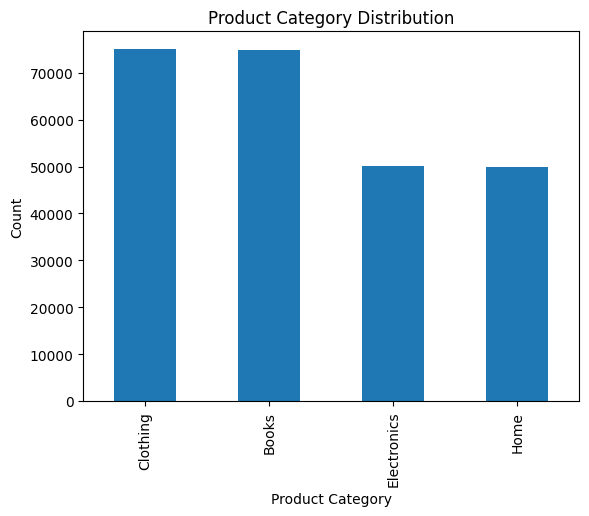

In [14]:
# Product Category Distribution (Bar Chart)

df["Product Category"].value_counts().plot(kind="bar")

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Count")

plt.show()

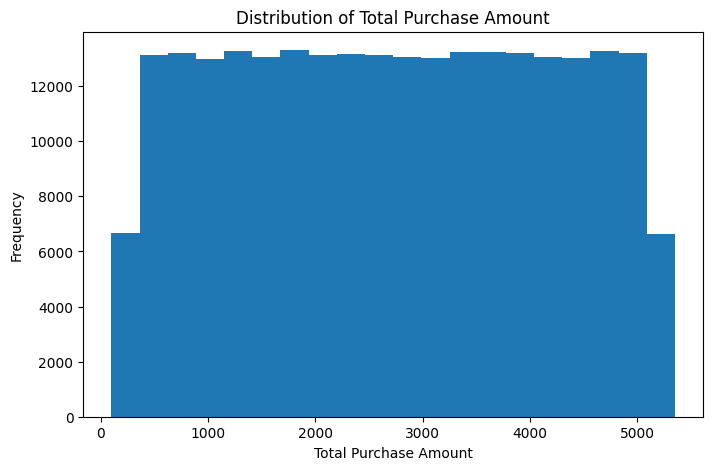

In [15]:
# Purchase Amount Distribution (Histogram)

plt.figure(figsize=(8,5))

plt.hist(df["Total Purchase Amount"], bins=20)

plt.title("Distribution of Total Purchase Amount")
plt.xlabel("Total Purchase Amount")
plt.ylabel("Frequency")

plt.show()

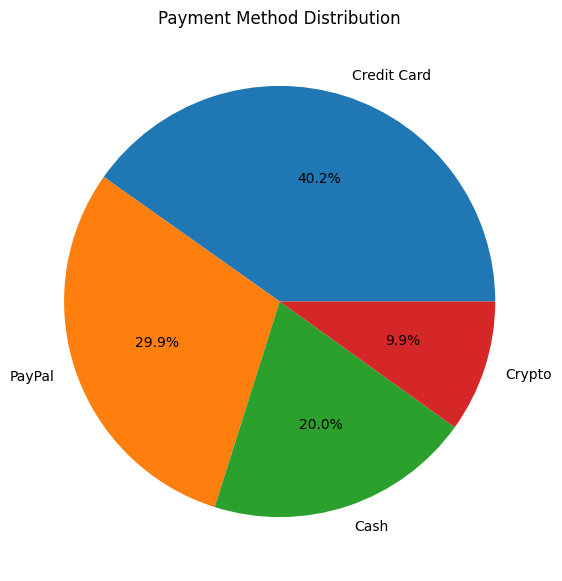

In [16]:
# Payment Method Distribution (Pie Chart)

payment_counts = df["Payment Method"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%')

plt.title("Payment Method Distribution")

plt.show()

In [17]:
# Convert purchase date into datetime format

df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

# Create reference date
reference_date = df["Purchase Date"].max()

# RFM table
rfm = df.groupby("Customer ID").agg({
    "Purchase Date": lambda x: (reference_date - x.max()).days,
    "Customer ID":"count",
    "Total Purchase Amount":"sum"
})

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,3491
2,298,3,7988
3,88,8,22587
4,126,4,8715
5,170,8,12524


In [18]:
# Customer segmentation

rfm["Segment"] = "Regular"

rfm.loc[
    (rfm["Frequency"] > rfm["Frequency"].median()) &
    (rfm["Monetary"] > rfm["Monetary"].median()),
    "Segment"
] = "High Value"

rfm.loc[
    (rfm["Recency"] > rfm["Recency"].median()),
    "Segment"
] = "At Risk"

rfm["Segment"].value_counts()

,count
Segment,
At Risk,24815
Regular,13392
High Value,11466


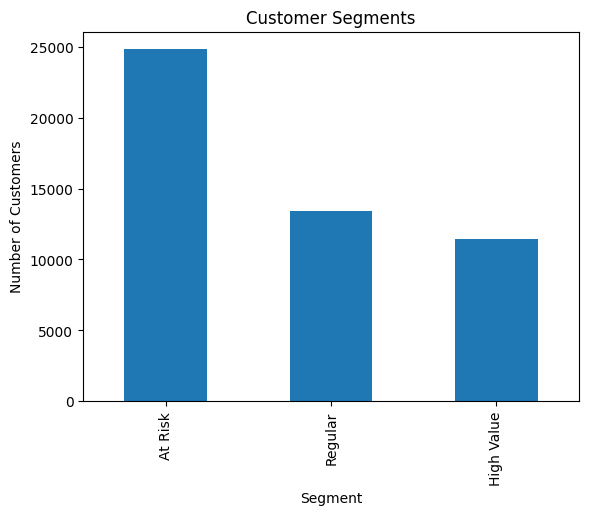

In [19]:
# Customer Segment Visualization

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

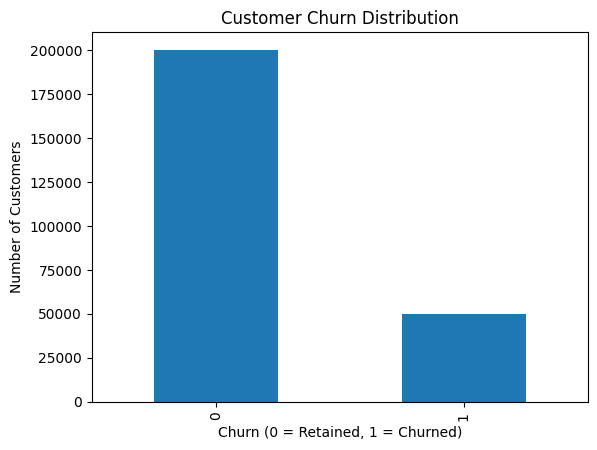

In [20]:
# Churn Distribution

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

**Executive Summary**

This project analyzes customer behavior using an e-commerce dataset containing 250,000 transaction records. Data cleaning and exploratory data analysis (EDA) were performed to identify customer purchase patterns, payment preferences, customer segments, and churn trends.

The analysis showed that Clothing and Books were the most purchased product categories, while Electronics and Home categories had comparatively lower purchase frequencies. Credit Card was the most preferred payment method, followed by PayPal. Purchase behavior also showed varying spending patterns across customers.

Customer segmentation using RFM (Recency, Frequency, Monetary) analysis categorized customers into High Value, Regular, and At Risk groups. The At Risk segment represented the largest customer group, indicating a need for stronger retention strategies. Churn analysis also showed that although customer retention was high, a considerable number of customers still left the platform.

The findings suggest that Alfido Tech can improve customer engagement through targeted retention campaigns, loyalty programs, and category-specific promotions.

**Actionable Recommendations for Alfido Tech**

1. Focus retention campaigns on At Risk customers using personalized offers and reminder campaigns.
2. Implement loyalty programs for High Value customers to increase repeat purchases and customer lifetime value.
3. Increase promotions for Electronics and Home products to improve category performance.
4. Optimize payment systems around Credit Card and PayPal because customers use them most frequently.
5. Develop churn prediction systems and targeted interventions for customers showing reduced activity.

